# Tree-DTW playground

Interactive tests + visualization for `network_matching.tree_dtw.match_tree_to_bgraph` — the
**standalone** matcher of a directed source *tree* onto a directed target network
(spec: `docs/tree_dtw_matching.md`). It builds the forward `D` / backward `B` cost tables, does the
joint `D+B−E` traceback, and returns the **matching relation `M`** (a set of `(a_point, b_point)`
pairs; a 1:N coverage run gives a point several pairs). No DAG matcher is involved.

Each figure: **blue** = source tree `A`, **orange** = target network `B`, thin lines = the
correspondence `M` (colored by drift).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import importlib
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import network_matching.tree_dtw as _tdtw
importlib.reload(_tdtw)                       # force the CURRENT on-disk code (avoids a stale kernel)
from network_matching.tree_dtw import match_tree_to_bgraph, check_tree_rules
from network_matching.dag_synthetic import get_dag
from network_matching.dag_playground import perturb_dag
print("tree_dtw from:", _tdtw.__file__)
print("back-pointer build (should be True):", hasattr(_tdtw, "_extract") and hasattr(_tdtw, "_segment_tables"))
%matplotlib inline

tree_dtw from: /home/kaveh/projects/network-matching/network_matching/tree_dtw.py
back-pointer build (should be True): True


In [2]:
def _ls(edges):
    return [(e, g if hasattr(g, "coords") else LineString(g)) for e, g in edges]

def summarize(res):
    runs = [len(m["run"]) for m in res["a_match"]]
    print("routes:", res["routes"])
    if "rules" in res:
        print("valid (V1-V4):", res["rules"]["ok"],
              "" if res["rules"]["ok"] else {k: v for k, v in res["rules"].items() if k != "ok" and v})
    print(f"M: {len(res['M'])} pairs over {len(res['a_match'])} source points; "
          f"max coverage run = {max(runs)} (a run > 1 is a 1:N match)")

def plot_match(res, a_edges, b_edges, title="", sep=None):
    """A stays at its real position (bottom); B is LIFTED by `sep` (top) so the two networks never
    overlap. segment mode: each matched (A-seg, B-seg) pair is drawn in ONE distinct color -- both
    segments + a dotted middle→middle link + a shared index -- so you can read which maps to which
    even where links cross. point mode: A-point→B-point links colored by drift."""
    ga, gb = res["GA"], res["GB"]
    seg = res.get("segment_pairs")
    allx = list(ga.vx) + list(gb.vx); ally = list(ga.vy) + list(gb.vy)
    span = max(max(allx) - min(allx), max(ally) - min(ally)) or 1.0
    dy = (0.55 * span) if sep is None else sep          # lift B by this much for a clean gap

    fig, ax = plt.subplots(figsize=(11, 7))
    for _e, g in _ls(a_edges):                          # faint background: A real, B lifted
        xs, ys = zip(*g.coords); ax.plot(xs, ys, "-", color="#3b6ea5", lw=2, alpha=.30, zorder=1)
    for _e, g in _ls(b_edges):
        xs, ys = zip(*g.coords); ax.plot(xs, [y + dy for y in ys], "-", color="#e8964a", lw=2, alpha=.30, zorder=1)

    if seg:                                             # ---- segment-to-segment ----
        cmap = plt.cm.get_cmap("tab20", max(len(seg), 1))
        for i, p in enumerate(seg):
            c = cmap(i)
            (ax0, ay0), (ax1, ay1) = p["a_p0"], p["a_p1"]
            (bx0, by0), (bx1, by1) = p["b_p0"], p["b_p1"]
            ax.plot([ax0, ax1], [ay0, ay1], "-", color=c, lw=4, solid_capstyle="round", zorder=3)          # A seg
            ax.plot([bx0, bx1], [by0 + dy, by1 + dy], "-", color=c, lw=4, solid_capstyle="round", zorder=3) # B seg (lifted)
            (mxa, mya), (mxb, myb) = p["a_mid"], p["b_mid"]
            ax.plot([mxa, mxb], [mya, myb + dy], ":", color=c, lw=1.1, alpha=.9, zorder=2)                   # mid→mid
            ax.annotate(str(i), (mxa, mya), color=c, fontsize=8, weight="bold", zorder=5)
            ax.annotate(str(i), (mxb, myb + dy), color=c, fontsize=8, weight="bold", zorder=5)
    else:                                               # ---- point-to-point ----
        dmax = max((m["drift"] for m in res["a_match"]), default=1.0) or 1.0
        for m in res["a_match"]:
            for w in m["run"]:
                ax.plot([m["ax"], gb.vx[w]], [m["ay"], gb.vy[w] + dy], "-", color="0.85", lw=.6, zorder=1)
            ax.plot([m["ax"], m["bx"]], [m["ay"], m["by"] + dy], "-",
                    color=plt.cm.viridis(min(m["drift"] / dmax, 1.0)), lw=1.1, zorder=3)

    ax.scatter(ga.vx, ga.vy, s=12, color="#3b6ea5", zorder=4, label="A (source)")
    ax.scatter(gb.vx, [y + dy for y in gb.vy], s=11, color="#e8964a", zorder=4, label="B (target, lifted)")
    ax.set_aspect("equal")
    ax.set_title(title + ("  ·  segment: matched pairs share a color + index" if seg
                          else "  ·  point: point→point (B lifted)"))
    ax.legend(loc="best", fontsize=8); plt.show()

## 1. A branching source (`y_split`)
One road splits into two; the B network splits the same way.

routes: {'A_main': ['B_main'], 'A_left': ['B_left'], 'A_right': ['B_right']}
valid (V1-V4): True 
M: 32 pairs over 31 source points; max coverage run = 2 (a run > 1 is a 1:N match)


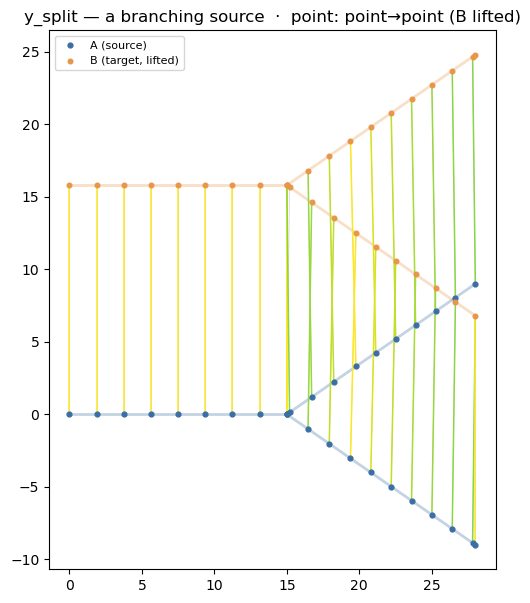

In [3]:
sc = get_dag("y_split")
res = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, sc["a_edges"], sc["b_edges"], "y_split — a branching source")

## 2. A merge
Two roads join into one; the incoming B-tails belong to the upstream branches, the merge point to `A_out`.

routes: {'A_bot': ['B_bot'], 'A_top': ['B_bot'], 'A_out': ['B_out']}
valid (V1-V4): True 
M: 34 pairs over 33 source points; max coverage run = 2 (a run > 1 is a 1:N match)


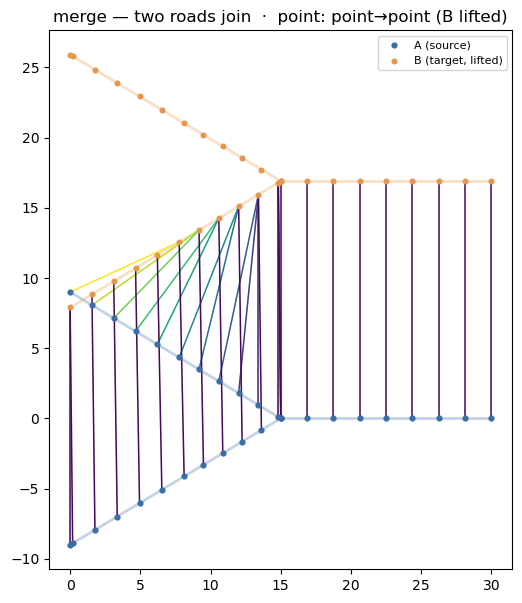

In [4]:
sc = get_dag("merge")
res = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, sc["a_edges"], sc["b_edges"], "merge — two roads join")

## 3. Coverage weight `α`
`α ≤ 1` discounts the emission on a horizontal (1:N) coverage step, so it stays cheap when B is sampled finer than A. `α = 1` is the plain per-point charge. The matching stays valid at every `α`.

In [5]:
sc = get_dag("merge")
for a in (1.0, 0.5, 0.2):
    r = match_tree_to_bgraph(sc["a_edges"], sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0,
                             horizontal_weight=a, validate=True)
    runs = [len(m["run"]) for m in r["a_match"]]
    print(f"alpha={a}:  valid={r['rules']['ok']}  pairs={len(r['M'])}  max_run={max(runs)}")

alpha=1.0:  valid=True  pairs=34  max_run=2
alpha=0.5:  valid=True  pairs=34  max_run=2
alpha=0.2:  valid=True  pairs=34  max_run=2


## 4. Perturbation
Rigidly shift the whole tree north (junctions stay stitched) and re-match.

routes: {'A_main': ['B_main'], 'A_left': ['B_left'], 'A_right': ['B_left']}
valid (V1-V4): True 
M: 31 pairs over 30 source points; max coverage run = 2 (a run > 1 is a 1:N match)


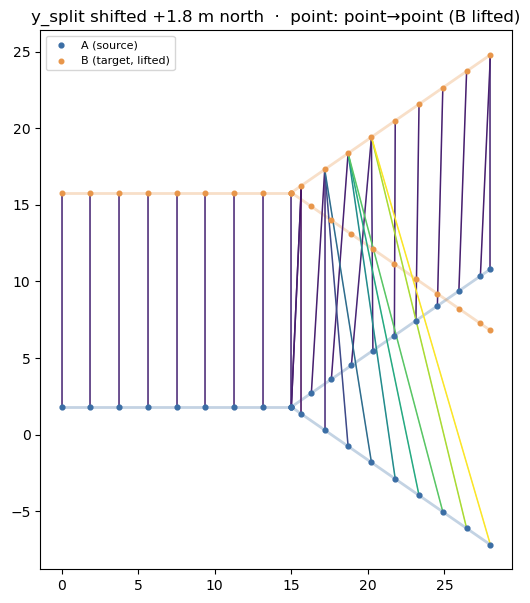

In [6]:
sc = get_dag("y_split")
A = [(e, LineString([(x, y + 1.8) for x, y in g.coords])) for e, g in sc["a_edges"]]
res = match_tree_to_bgraph(A, sc["b_edges"], snap_tolerance_m=0.5, step_meters=2.0, validate=True)
summarize(res)
plot_match(res, A, sc["b_edges"], "y_split shifted +1.8 m north")

## 5. Build your own tree
Edges are plain coordinate lists; coincident endpoints get stitched into junctions.

routes: {'stem': ['stem'], 'down': ['down'], 'up': ['down']}
valid (V1-V4): True 
M: 30 pairs over 29 source points; max coverage run = 2 (a run > 1 is a 1:N match)


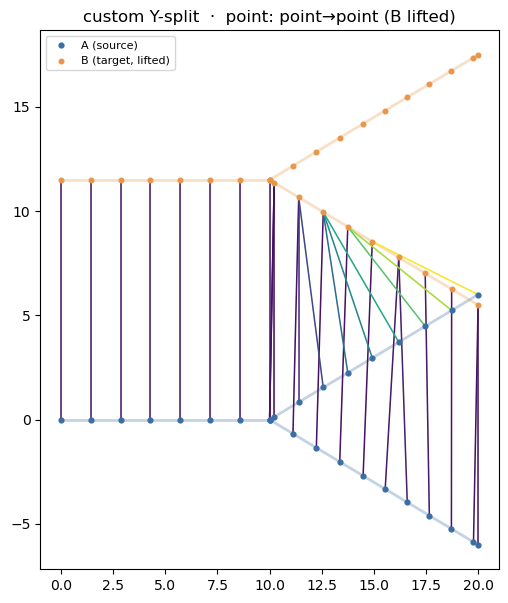

In [7]:
a_edges = [("stem", [(0, 0), (10, 0)]),
           ("up",   [(10, 0), (20, 6)]),
           ("down", [(10, 0), (20, -6)])]
b_edges = [("stem", [(0, 0.5), (10, 0.5)]),
           ("up",   [(10, 0.5), (20, 6.5)]),
           ("down", [(10, 0.5), (20, -5.5)])]
res = match_tree_to_bgraph(a_edges, b_edges, snap_tolerance_m=0.75, step_meters=1.5, validate=True)
summarize(res)
plot_match(res, a_edges, b_edges, "custom Y-split")

routes: {'stem': ['stem'], 'down': ['stem'], 'up': ['up']}
valid (V1-V4): False {'v1_cross': [(0, 14), (2, 14), (13, 14), (6, 14), (4, 14), (7, 14), (3, 14), (14, 14), (5, 14)], 'v2_predecessor': [(0, 14)], 'v3_successor': [(15, 15)]}
M: 35 pairs over 24 source points; max coverage run = 2 (a run > 1 is a 1:N match)


/tmp/ipykernel_3074646/2189217511.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(seg), 1))


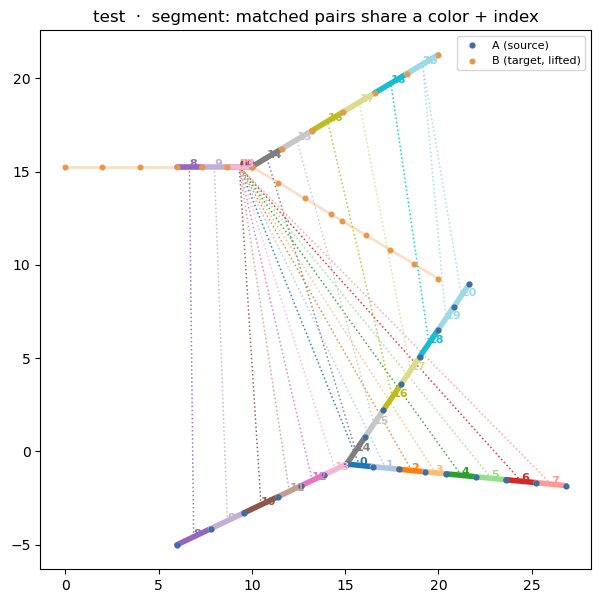

In [8]:
A = perturb_dag(a_edges, shift=5, rotate=25, noise=0.1, seed=10)   # move the whole DAG rigidly
res = match_tree_to_bgraph(A, b_edges, emission="segment", bearing_weight=0.31, validate=True)
summarize(res)                       # prints routes + "valid (V1-V4): True/False"
plot_match(res, A, b_edges, "test")

--- emission=point ---
routes: {'A1': ['B1', 'B2'], 'A2': ['B2']}
valid (V1-V4): True 
M: 14 pairs over 13 source points; max coverage run = 2 (a run > 1 is a 1:N match)


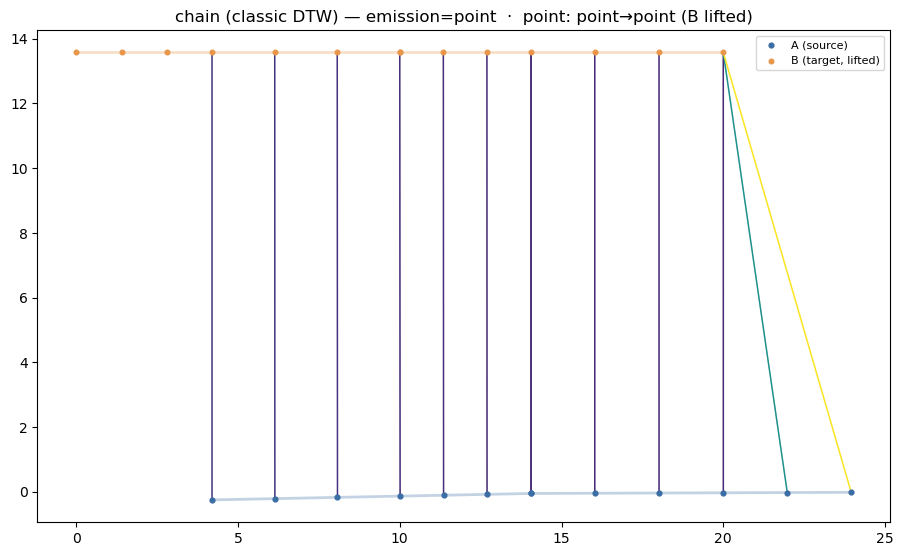

--- emission=segment ---
routes: {'A1': ['B1', 'B2'], 'A2': ['B2']}
valid (V1-V4): False {'v1_cross': [(11, 12)]}
M: 16 pairs over 13 source points; max coverage run = 2 (a run > 1 is a 1:N match)


/tmp/ipykernel_3074646/2189217511.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(seg), 1))


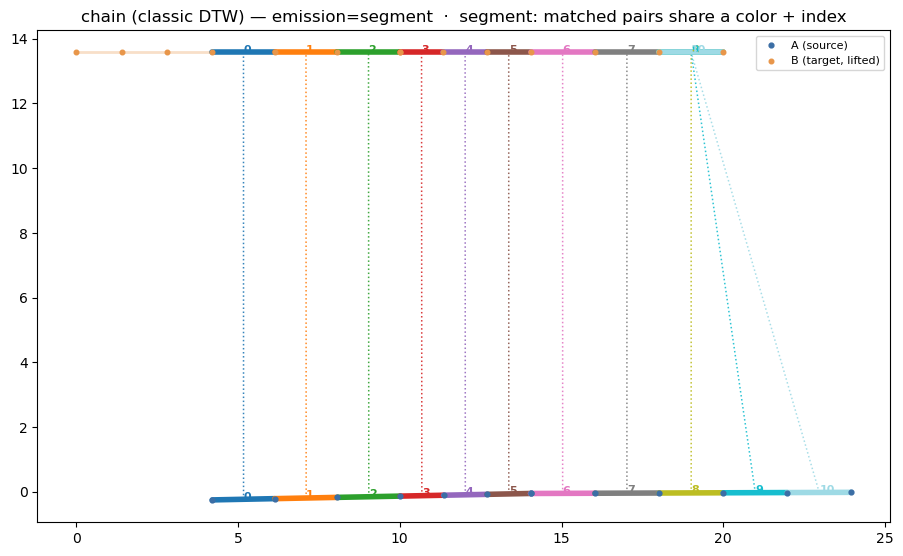

In [9]:
# A 2-edge CHAIN (no split/merge) = classic DTW, shifted so A slides along B.
# NOTE: pass validate=True or summarize() won't print the V1-V4 line -- routes alone don't show validity!
A = [("A1", [(0,0),(10,0)]), ("A2", [(10,0),(20,0)])]
A_shifted = perturb_dag(A, shift=4, rotate=0, noise=0.1, seed=3)
B = [("B1", [(0,0.4),(10,0.4)]), ("B2", [(10,0.4),(20,0.4)])]
for mode, kw in [("point", {}), ("segment", dict(emission="segment", bearing_weight=2.0))]:
    res = match_tree_to_bgraph(A_shifted, B, validate=True, **kw)   # validate=True -> summarize shows V1-V4
    print(f"--- emission={mode} ---")
    summarize(res)                 # point: valid ; segment: currently INVALID (V1 cross) -- known extraction bug
    plot_match(res, A_shifted, B, f"chain (classic DTW) — emission={mode}")

## 6. Segment-to-segment matching (docs §8)
`emission="segment"` is **true segment-to-segment**: a DP state is an `(A-arc, B-arc)` pair, scored
middle-to-middle `+ bearing_weight·Δbearing` on *every* move (not a midpoint cost on point states).
Under a lateral shift a narrow fork's arm collapses onto the nearest B-arm in point mode; segment mode
keeps each arm on the same-heading B-arm. **The figure changes:** segment mode draws each link from an
**A-segment middle to its matched B-segment middle** (the pairs the DP scored), instead of A-point → B-point.

--- emission=point ---
routes: {'stem': ['stem'], 'dn': ['up'], 'up': ['up']}
valid (V1-V4): True 
M: 33 pairs over 32 source points; max coverage run = 2 (a run > 1 is a 1:N match)


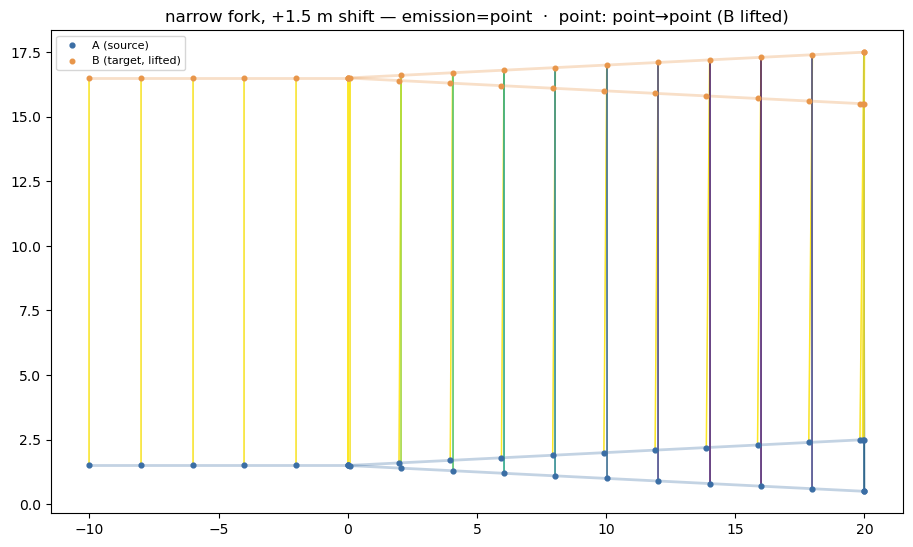

/tmp/ipykernel_3074646/2189217511.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(seg), 1))


--- emission=segment ---
routes: {'stem': ['stem'], 'dn': ['dn'], 'up': ['up']}
valid (V1-V4): True 
M: 35 pairs over 32 source points; max coverage run = 2 (a run > 1 is a 1:N match)


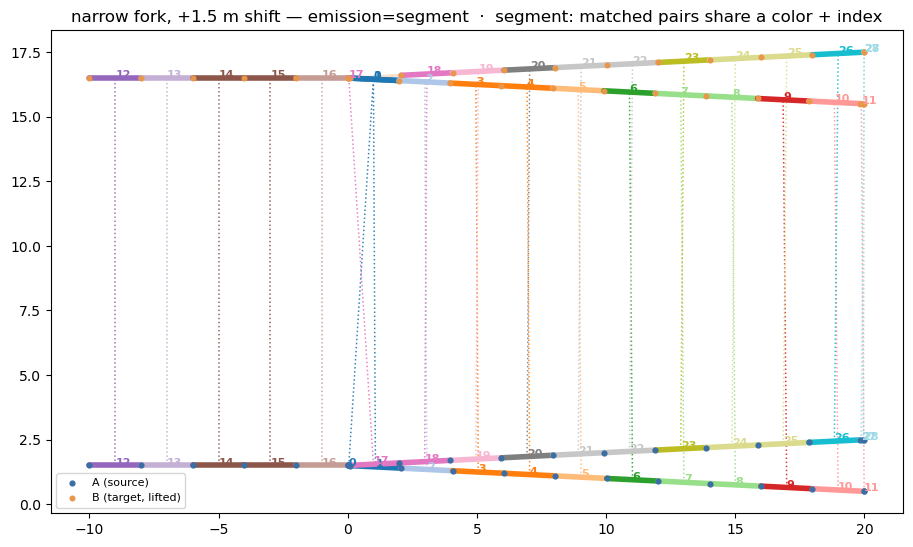

In [10]:
# Narrow fork, shifted +1.5 m north: the `dn` arm's far end sits nearer the target's `up` arm, so
# point mode mis-routes dn->up; segment mode keeps dn->dn. (Self-contained; not tied to cells above.)
def narrow_fork(hw, dy=0.0):
    return [("stem", [(-10, dy), (0, dy)]),
            ("up",   [(0, dy), (20,  hw + dy)]),
            ("dn",   [(0, dy), (20, -hw + dy)])]

nf_b, nf_a = narrow_fork(1.0), narrow_fork(1.0, dy=1.5)
for mode, kw in [("point", {}), ("segment", dict(emission="segment", bearing_weight=3.0))]:
    res = match_tree_to_bgraph(nf_a, nf_b, snap_tolerance_m=0.5, step_meters=2.0, validate=True, **kw)
    print(f"--- emission={mode} ---")
    summarize(res)                          # point: dn -> B_up (WRONG); segment: dn -> B_dn (fixed)
    plot_match(res, nf_a, nf_b, f"narrow fork, +1.5 m shift — emission={mode}")